In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ── 1. Load data ───────────────────────────────────────────────────────────────
ip1_path = r"C:/Hackathon-GSK/Final_Submission/data/cleaned_data/SAP/260109_ZQM105_IP1_P030_PURIF_cleanedApr28.csv"
ip2_path = r"C:/Hackathon-GSK/Final_Submission/data/cleaned_data/SAP/260109_ZQM105_IP2_P030_PURIF_cleanedApr28.csv"
ip3_path = r"C:/Hackathon-GSK/Final_Submission/data/cleaned_data/SAP/260109_ZQM105_IP3_P030_PURIF_cleanedApr28.csv"

YIELD_COL = "GY_011 PSV - Global Yield total [%]"

df_ip1 = pd.read_csv(ip1_path)
df_ip2 = pd.read_csv(ip2_path)
df_ip3 = pd.read_csv(ip3_path)

df_ip1["IP"] = "IP1"
df_ip2["IP"] = "IP2"
df_ip3["IP"] = "IP3"

C:\Users\narmine.baouab\AppData\Local\Temp\ipykernel_37880\2339787044.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_ip1["IP"] = "IP1"
C:\Users\narmine.baouab\AppData\Local\Temp\ipykernel_37880\2339787044.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_ip2["IP"] = "IP2"
C:\Users\narmine.baouab\AppData\Local\Temp\ipykernel_37880\2339787044.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all c

# Shared Collumns

In [7]:
all_cols    = set(df_ip1.columns) | set(df_ip2.columns) | set(df_ip3.columns)
shared_cols = set(df_ip1.columns) & set(df_ip2.columns) & set(df_ip3.columns)

only_ip1 = set(df_ip1.columns) - set(df_ip2.columns) - set(df_ip3.columns)
only_ip2 = set(df_ip2.columns) - set(df_ip1.columns) - set(df_ip3.columns)
only_ip3 = set(df_ip3.columns) - set(df_ip1.columns) - set(df_ip2.columns)

print(f"Total unique columns across all files : {len(all_cols)}")
print(f"Shared across all 3                   : {len(shared_cols)}")
print(f"Dropped (not in all 3)                : {len(all_cols) - len(shared_cols)}")
print(f"\n  Only in IP1 : {len(only_ip1)} → {sorted(only_ip1)}")
print(f"  Only in IP2 : {len(only_ip2)} → {sorted(only_ip2)}")
print(f"  Only in IP3 : {len(only_ip3)} → {sorted(only_ip3)}")

Total unique columns across all files : 151
Shared across all 3                   : 132
Dropped (not in all 3)                : 19

  Only in IP1 : 4 → ['DEAE_026 DEAE - Bioburden [CFU/ml]', 'clarif_3rd check corr. (pass/fail)', 'clarif_Corrected Parameter', 'clarif_Corrected Parameter.3']
  Only in IP2 : 2 → ['clarif_014 Protein Lowry (virus cult) [µg/ml]', 'clarif_Perf 1vol1/2-Vol medium tr. [Liter]']
  Only in IP3 : 1 → ['NF_Clarif 2 - Nr of train_missing_flag']


# PCA 
## IP 1 | IP 2 | IP 3 comparaison

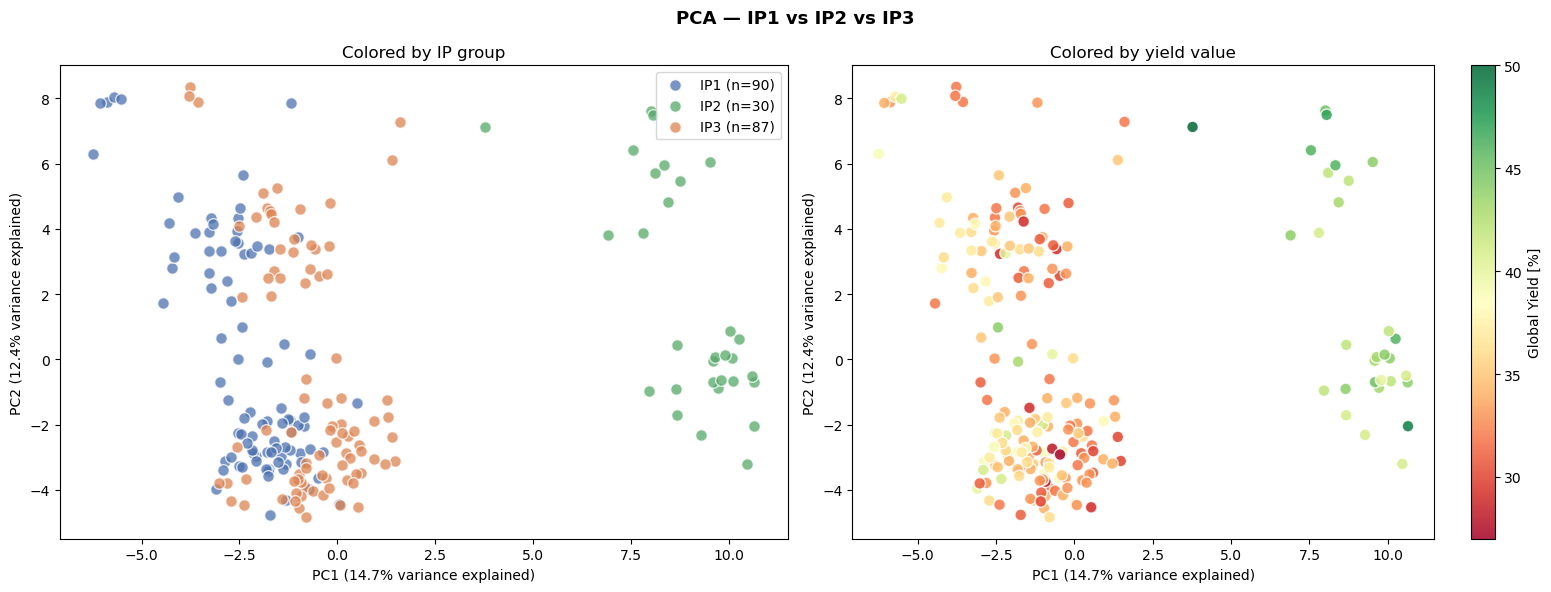

Yield range — min: 27.0% | max: 50.0% | mean: 35.7%


In [ ]:
# ──  Plot — colored by yield ─────────────────────────────────────────────────

# Need yield values aligned with df_clean
df_clean2 = df_all[feature_cols + ["IP", YIELD_COL]].dropna()

X2      = df_clean2[feature_cols].values
labels2 = df_clean2["IP"].values
y2      = df_clean2[YIELD_COL].values

X_scaled2 = StandardScaler().fit_transform(X2)
pca2      = PCA(n_components=2)
X_2d2     = pca2.fit_transform(X_scaled2)
var1_2, var2_2 = pca2.explained_variance_ratio_ * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: colored by IP group ---
colors = {"IP1": "#4C72B0", "IP2": "#55A868", "IP3": "#DD8452"}
for ip in ["IP1", "IP2", "IP3"]:
    mask = labels2 == ip
    axes[0].scatter(X_2d2[mask, 0], X_2d2[mask, 1],
                    label=f"{ip} (n={mask.sum()})",
                    color=colors[ip], alpha=0.75, edgecolors="white", s=70)
axes[0].set_xlabel(f"PC1 ({var1_2:.1f}% variance explained)")
axes[0].set_ylabel(f"PC2 ({var2_2:.1f}% variance explained)")
axes[0].set_title("Colored by IP group")
axes[0].legend()

# --- Right: colored by yield ---
sc = axes[1].scatter(X_2d2[:, 0], X_2d2[:, 1],
                     c=y2, cmap="RdYlGn", alpha=0.85,
                     edgecolors="white", s=70)
plt.colorbar(sc, ax=axes[1], label="Global Yield [%]")
axes[1].set_xlabel(f"PC1 ({var1_2:.1f}% variance explained)")
axes[1].set_ylabel(f"PC2 ({var2_2:.1f}% variance explained)")
axes[1].set_title("Colored by yield value")

plt.suptitle("PCA — IP1 vs IP2 vs IP3", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Yield range — min: {y2.min():.1f}% | max: {y2.max():.1f}% | mean: {y2.mean():.1f}%")

Out of the 132 shared columns, we drop:

- 1 → the yield column (YIELD_COL) — it's the target, not a feature
- 18 → non-numeric columns (text, categorical, flags like pass/fail) — PCA only works on numbers

So: 132 − 1 − 18 = 113 numeric features used for PCA.

Really informative. Here's what the yield plot reveals:

IP2 has systematically higher yields than IP1 and IP3

- IP2 cluster (right) → mostly green (yield ~40–50%)
- IP1 + IP3 cluster (left) → mostly orange/red (yield ~28–38%)


Key findings combined:

Observation 
IP2 separated on PC1 + greener yields 

Meaning
IP2 runs at a fundamentally different (and better-performing) process condition

Observation
IP1 & IP3 overlap + similar yield range

Meaning
Same process family, similar yield levels — combining them for modelling was the right call

Observation
Yield doesn't separate cleanly within the IP1+IP3 

Meaning
clusterYield variation inside IP1/IP3 is subtle — captured by higher PCs, not PC1/PC2 alone


What this means for your report:

The PCA confirms two things — (1) your modelling choice to combine IP1+IP3 was justified by their process similarity, and (2) IP2 is a separate regime that would need its own model. The yield difference between IP2 and IP1/IP3 is likely driven by the process changes that define IP2, not noise.


Want me to add a 3rd plot showing yield distribution per IP as a boxplot to make this even clearer for the report?

## IP 1  | IP 3 comparaison

Batches — IP1: 90 | IP3: 87
Yield — min: 27.0% | max: 44.0% | mean: 34.4% | median: 34.0%


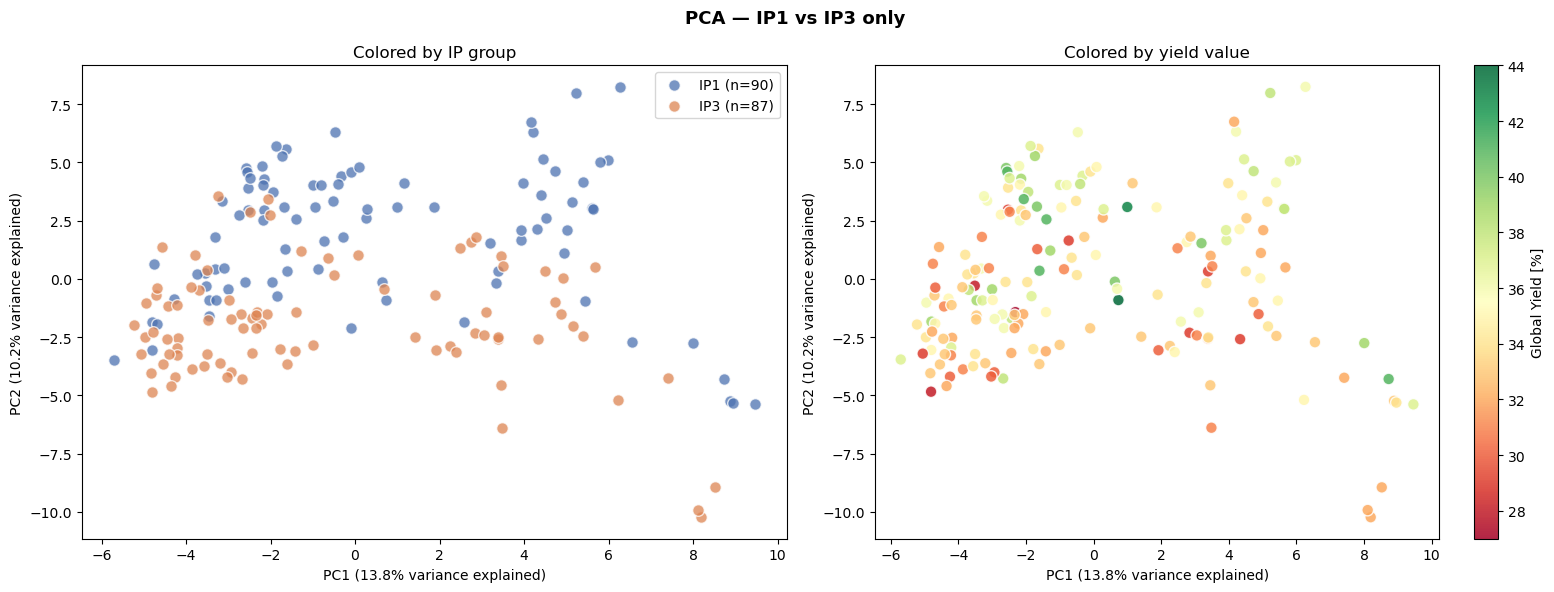

In [10]:
# ── PCA: IP1 & IP3 only — colored by yield ────────────────────────────────────

shared_13 = list(set(df_ip1.columns) & set(df_ip3.columns))

df_ip1_s = df_ip1[shared_13].copy(); df_ip1_s["IP"] = "IP1"
df_ip3_s = df_ip3[shared_13].copy(); df_ip3_s["IP"] = "IP3"
df_13 = pd.concat([df_ip1_s, df_ip3_s], ignore_index=True)

feature_cols_13 = [c for c in shared_13
                   if c != YIELD_COL
                   and pd.api.types.is_numeric_dtype(df_13[c])]

df_13_clean = df_13[feature_cols_13 + ["IP", YIELD_COL]].dropna()

X13      = df_13_clean[feature_cols_13].values
labels13 = df_13_clean["IP"].values
y13      = df_13_clean[YIELD_COL].values

X13_scaled  = StandardScaler().fit_transform(X13)
pca13       = PCA(n_components=2)
X13_2d      = pca13.fit_transform(X13_scaled)
var1, var2  = pca13.explained_variance_ratio_ * 100

print(f"Batches — IP1: {(labels13=='IP1').sum()} | IP3: {(labels13=='IP3').sum()}")
print(f"Yield — min: {y13.min():.1f}% | max: {y13.max():.1f}% | mean: {y13.mean():.1f}% | median: {np.median(y13):.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: colored by IP ---
colors = {"IP1": "#4C72B0", "IP3": "#DD8452"}
for ip in ["IP1", "IP3"]:
    mask = labels13 == ip
    axes[0].scatter(X13_2d[mask, 0], X13_2d[mask, 1],
                    label=f"{ip} (n={mask.sum()})",
                    color=colors[ip], alpha=0.75, edgecolors="white", s=70)
axes[0].set_xlabel(f"PC1 ({var1:.1f}% variance explained)")
axes[0].set_ylabel(f"PC2 ({var2:.1f}% variance explained)")
axes[0].set_title("Colored by IP group")
axes[0].legend()

# --- Right: colored by yield ---
sc = axes[1].scatter(X13_2d[:, 0], X13_2d[:, 1],
                     c=y13, cmap="RdYlGn", alpha=0.85,
                     edgecolors="white", s=70)
plt.colorbar(sc, ax=axes[1], label="Global Yield [%]")
axes[1].set_xlabel(f"PC1 ({var1:.1f}% variance explained)")
axes[1].set_ylabel(f"PC2 ({var2:.1f}% variance explained)")
axes[1].set_title("Colored by yield value")

plt.suptitle("PCA — IP1 vs IP3 only", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Thresold Determination

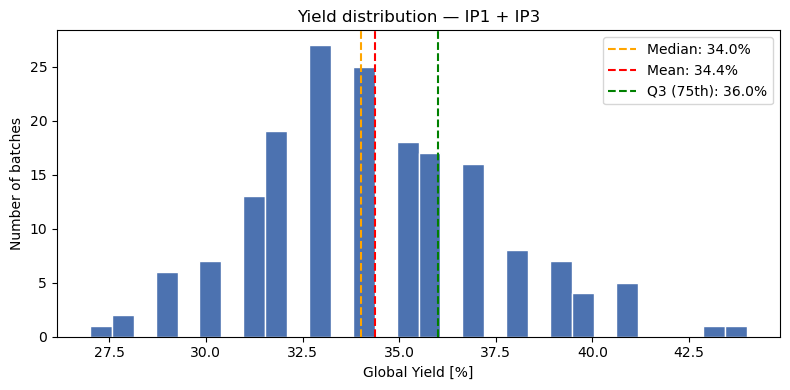

Q1 (25th percentile): 32.0%
Q3 (75th percentile): 36.0%


In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(y13, bins=30, color="#4C72B0", edgecolor="white")
ax.axvline(np.median(y13), color="orange", linestyle="--", label=f"Median: {np.median(y13):.1f}%")
ax.axvline(np.mean(y13),   color="red",    linestyle="--", label=f"Mean: {np.mean(y13):.1f}%")
ax.axvline(np.percentile(y13, 75), color="green", linestyle="--", label=f"Q3 (75th): {np.percentile(y13, 75):.1f}%")
ax.set_xlabel("Global Yield [%]")
ax.set_ylabel("Number of batches")
ax.set_title("Yield distribution — IP1 + IP3")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Q1 (25th percentile): {np.percentile(y13, 25):.1f}%")
print(f"Q3 (75th percentile): {np.percentile(y13, 75):.1f}%")

**The thresold decided is = median = 34%** 

# SEPERATE FINAL ONE

In [9]:
"""
PCA Exploration v2 — Per-IP Analysis & Sub-Step Investigation
=============================================================
Run each BLOCK independently and paste the output back for interpretation.
Each block is self-contained (re-loads data) so you can run in any order.
 
PATHS — adjust if needed
"""
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings("ignore")
 
# ── PATHS ──────────────────────────────────────────────────────────────────────
IP1_PATH = r"C:\Hackathon-GSK\data\processed\cleaned_data\SAP\260109_ZQM105_IP1_P030_PURIF_cleanedApr28.csv"
IP2_PATH = r"C:\Hackathon-GSK\data\processed\cleaned_data\SAP\260109_ZQM105_IP2_P030_PURIF_cleanedApr28.csv"
IP3_PATH = r"C:\Hackathon-GSK\data\processed\cleaned_data\SAP\260109_ZQM105_IP3_P030_PURIF_cleanedApr28.csv"
 
GLOBAL_YIELD_COL = "GY_011 PSV - Global Yield total [%]"
 
# Stage-level yield columns — adjust names to match your actual column names
STAGE_YIELD_COLS = {
    "Clarif":  "clarif_yield_ag_pct",   # adjust
    "UF":      "uf_yield_pct",          # adjust
    "PG":      "pg_yield_pct",          # adjust
    "PSV":     "psv_yield_pct",         # adjust
}
 
# Column prefixes per stage block — adjust to your naming convention
STAGE_PREFIXES = {
    "Clarif":  ["clarif", "up_", "harvest"],
    "UF":      ["uf_", "UF"],
    "PG":      ["pg_", "PG"],
    "PSV_DEAE":["psv_", "deae_", "PSV", "DEAE"],
}
 
 
# ══════════════════════════════════════════════════════════════════════════════
# HELPER FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════
 
def load_ip(path, ip_label):
    df = pd.read_csv(path)
    df["IP"] = ip_label
    return df
 
 
def get_numeric_features(df, exclude_cols):
    return [
        c for c in df.columns
        if pd.api.types.is_numeric_dtype(df[c])
        and c not in exclude_cols
    ]
 
 
def run_pca_2d(df, feature_cols, impute=True):
    X = df[feature_cols].values
    if impute:
        X = SimpleImputer(strategy="median").fit_transform(X)
    X_scaled = StandardScaler().fit_transform(X)
    pca = PCA(n_components=min(10, X.shape[1]))
    coords = pca.fit_transform(X_scaled)
    return coords, pca
 
 
def scree_plot(ax, pca, title="Scree Plot"):
    cumvar = np.cumsum(pca.explained_variance_ratio_ * 100)
    bars   = pca.explained_variance_ratio_ * 100
    n = len(bars)
    ax.bar(range(1, n+1), bars, color="#4C72B0", alpha=0.7, label="Per-PC variance")
    ax.plot(range(1, n+1), cumvar, "o-", color="#DD8452", lw=2, label="Cumulative")
    ax.axhline(60, color="gray", linestyle="--", lw=1, alpha=0.5)
    ax.set_xlabel("Principal Component")
    ax.set_ylabel("Variance Explained (%)")
    ax.set_title(title)
    ax.legend(fontsize=8)

BLOCK 1 — Per-IP PCA (each IP fitted independently)

IP1: n=90, features=107
  Yield — mean=35.6% | median=36.0% | std=3.1%
  PC1+PC2 variance explained: 25.8%
  PC1 mean coord — high-yield batches (top 25%): 0.25
  PC1 mean coord — low-yield batches (bot 25%):  -0.19
  >> Gap on PC1 (high - low): 0.44

IP2: n=30, features=106
  Yield — mean=43.6% | median=43.0% | std=2.4%
  PC1+PC2 variance explained: 33.3%
  PC1 mean coord — high-yield batches (top 25%): 3.46
  PC1 mean coord — low-yield batches (bot 25%):  -1.55
  >> Gap on PC1 (high - low): 5.01

IP3: n=87, features=106
  Yield — mean=33.1% | median=33.0% | std=2.4%
  PC1+PC2 variance explained: 25.5%
  PC1 mean coord — high-yield batches (top 25%): -0.41
  PC1 mean coord — low-yield batches (bot 25%):  0.81
  >> Gap on PC1 (high - low): -1.22


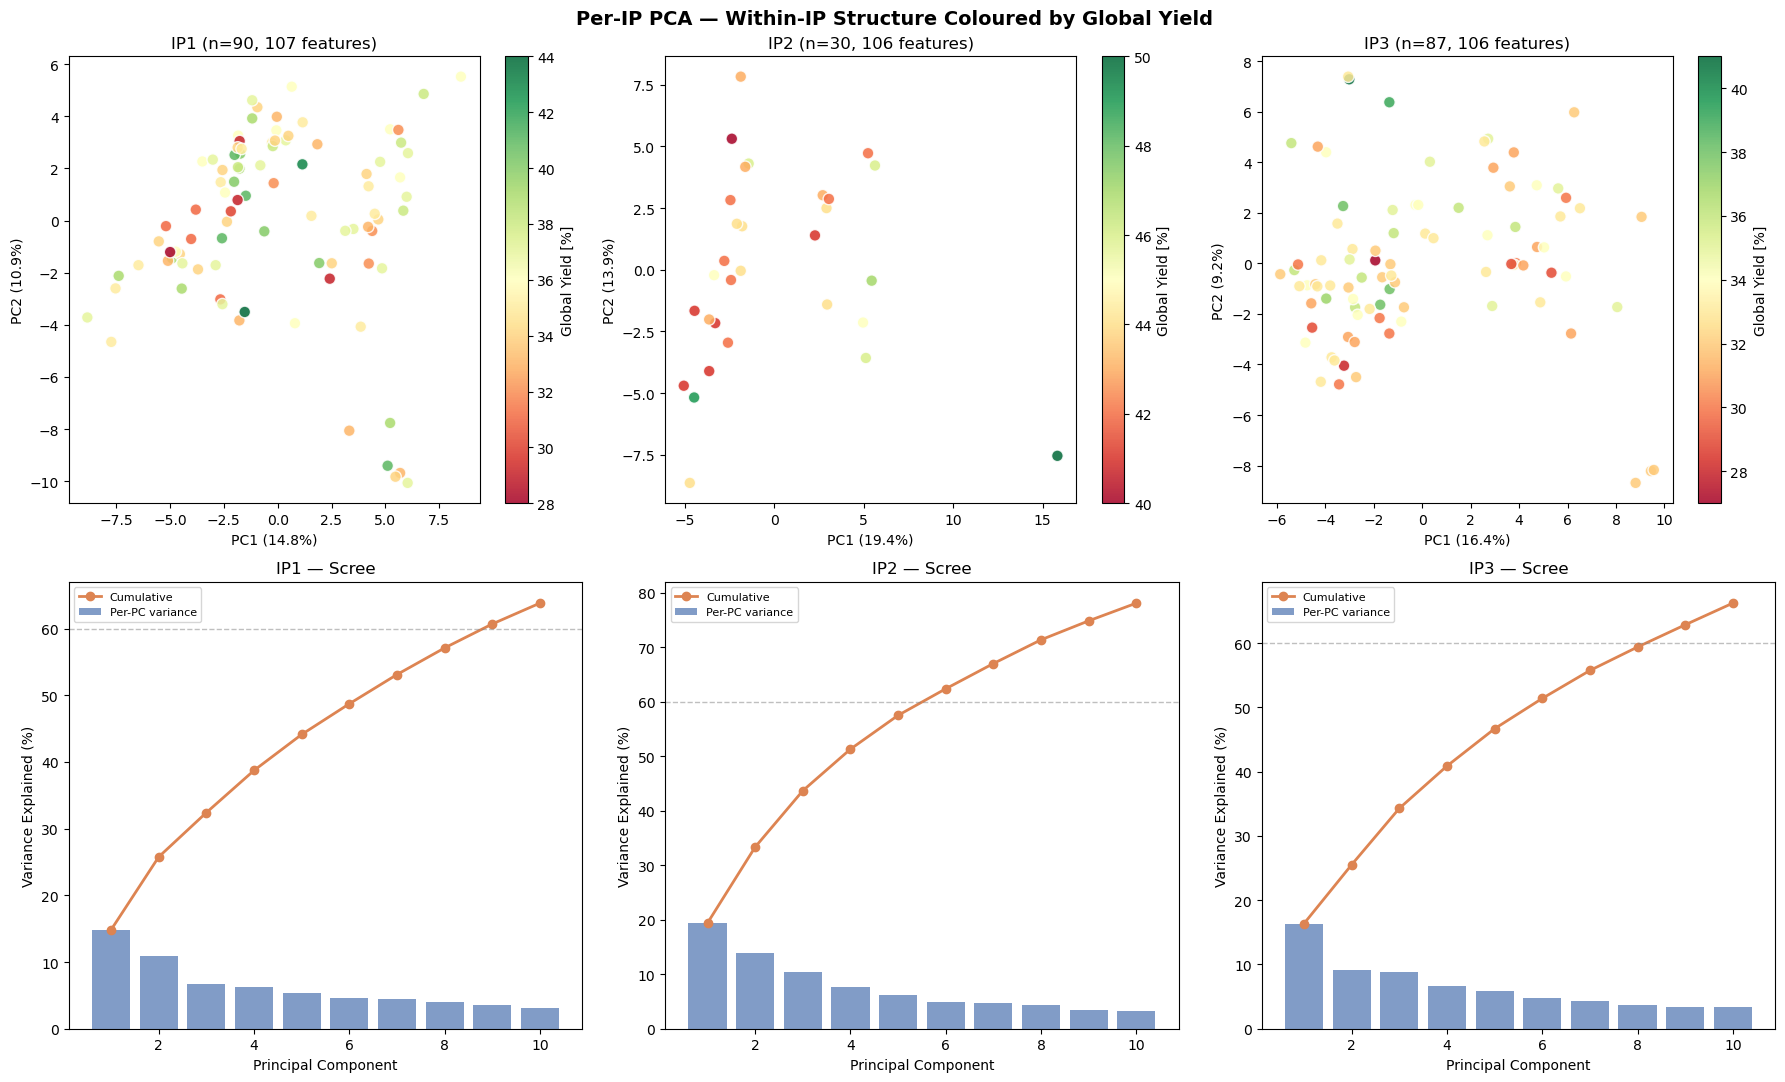


[BLOCK 1 DONE — share the plot + printed stats]


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOCK 1 — Per-IP PCA (IP1, IP2, IP3 each fitted separately)
# Goal: see within-IP structure coloured by global yield
# Key question: does yield separate inside each IP?
# ══════════════════════════════════════════════════════════════════════════════
print("=" * 70)
print("BLOCK 1 — Per-IP PCA (each IP fitted independently)")
print("=" * 70)
 
df_ip1 = load_ip(IP1_PATH, "IP1")
df_ip2 = load_ip(IP2_PATH, "IP2")
df_ip3 = load_ip(IP3_PATH, "IP3")
 
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Per-IP PCA — Within-IP Structure Coloured by Global Yield", fontsize=14, fontweight="bold")
 
for col_idx, (df, ip_label) in enumerate([(df_ip1, "IP1"), (df_ip2, "IP2"), (df_ip3, "IP3")]):
    exclude = [GLOBAL_YIELD_COL, "IP", "Batch"] + list(STAGE_YIELD_COLS.values())
    feat_cols = get_numeric_features(df, exclude_cols=exclude)
    # Drop near-constant columns (>95% same value)
    feat_cols = [c for c in feat_cols if df[c].nunique() > 3]
 
    df_c = df[feat_cols + [GLOBAL_YIELD_COL]].dropna(subset=[GLOBAL_YIELD_COL]).reset_index(drop=True)
    feat_cols_c = [c for c in feat_cols if c in df_c.columns]
 
    coords, pca = run_pca_2d(df_c, feat_cols_c)
    coords = coords[:, :2]
    y_vals = df_c[GLOBAL_YIELD_COL].values
    var1, var2 = pca.explained_variance_ratio_[:2] * 100
 
    # Scatter coloured by yield
    sc = axes[0, col_idx].scatter(
        coords[:, 0], coords[:, 1],
        c=y_vals, cmap="RdYlGn", alpha=0.85, edgecolors="white", s=70
    )
    plt.colorbar(sc, ax=axes[0, col_idx], label="Global Yield [%]")
    axes[0, col_idx].set_title(f"{ip_label} (n={len(df_c)}, {len(feat_cols_c)} features)")
    axes[0, col_idx].set_xlabel(f"PC1 ({var1:.1f}%)")
    axes[0, col_idx].set_ylabel(f"PC2 ({var2:.1f}%)")
 
    # Scree
    scree_plot(axes[1, col_idx], pca, title=f"{ip_label} — Scree")
 
    # Stats
    q75 = np.percentile(y_vals, 75)
    q25 = np.percentile(y_vals, 25)
    high_mask = y_vals >= q75
    low_mask  = y_vals <= q25
    print(f"\n{ip_label}: n={len(df_c)}, features={len(feat_cols_c)}")
    print(f"  Yield — mean={y_vals.mean():.1f}% | median={np.median(y_vals):.1f}% | std={y_vals.std():.1f}%")
    print(f"  PC1+PC2 variance explained: {var1+var2:.1f}%")
    print(f"  PC1 mean coord — high-yield batches (top 25%): {coords[high_mask, 0].mean():.2f}")
    print(f"  PC1 mean coord — low-yield batches (bot 25%):  {coords[low_mask,  0].mean():.2f}")
    print(f"  >> Gap on PC1 (high - low): {coords[high_mask, 0].mean() - coords[low_mask, 0].mean():.2f}")
 
plt.tight_layout()
plt.savefig("block1_per_ip_pca.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n[BLOCK 1 DONE — share the plot + printed stats]")

This is a simple but meaningful effect size. If the gap is small (say < 0.5 in standardised PCA space), it means top-25% and bottom-25% yield batches are not reliably separated along the dominant axis of variance — the features don't linearly encode yield differences. If the gap is large (> 1.5), there's a real geometric separation, which would justify using PC scores as engineered features in your Ridge model or as a sanity check that Ridge is solving a learnable problem.
What the scree plot tells you beyond variance explained: if PC1 alone captures 40–60% of variance, the dataset has strong internal structure — a few process variables co-vary tightly (e.g. all UF parameters move together). If variance is flat across PCs (each explaining ~5–10%), your features are relatively independent — no dominant process axis — which makes Ridge's L2 regularisation work harder because there's no obvious low-dimensional manifold to exploit.
The yield statistics printed here (mean, median, std per IP) are also diagnostically useful. If one IP has much lower yield variance (small std), then PCA will struggle to find a yield-correlated axis simply because there's not enough contrast between batches — a modelling challenge, not a data processing one.


BLOCK 2 — Stage-Block PCA per IP (which stage drives yield?)


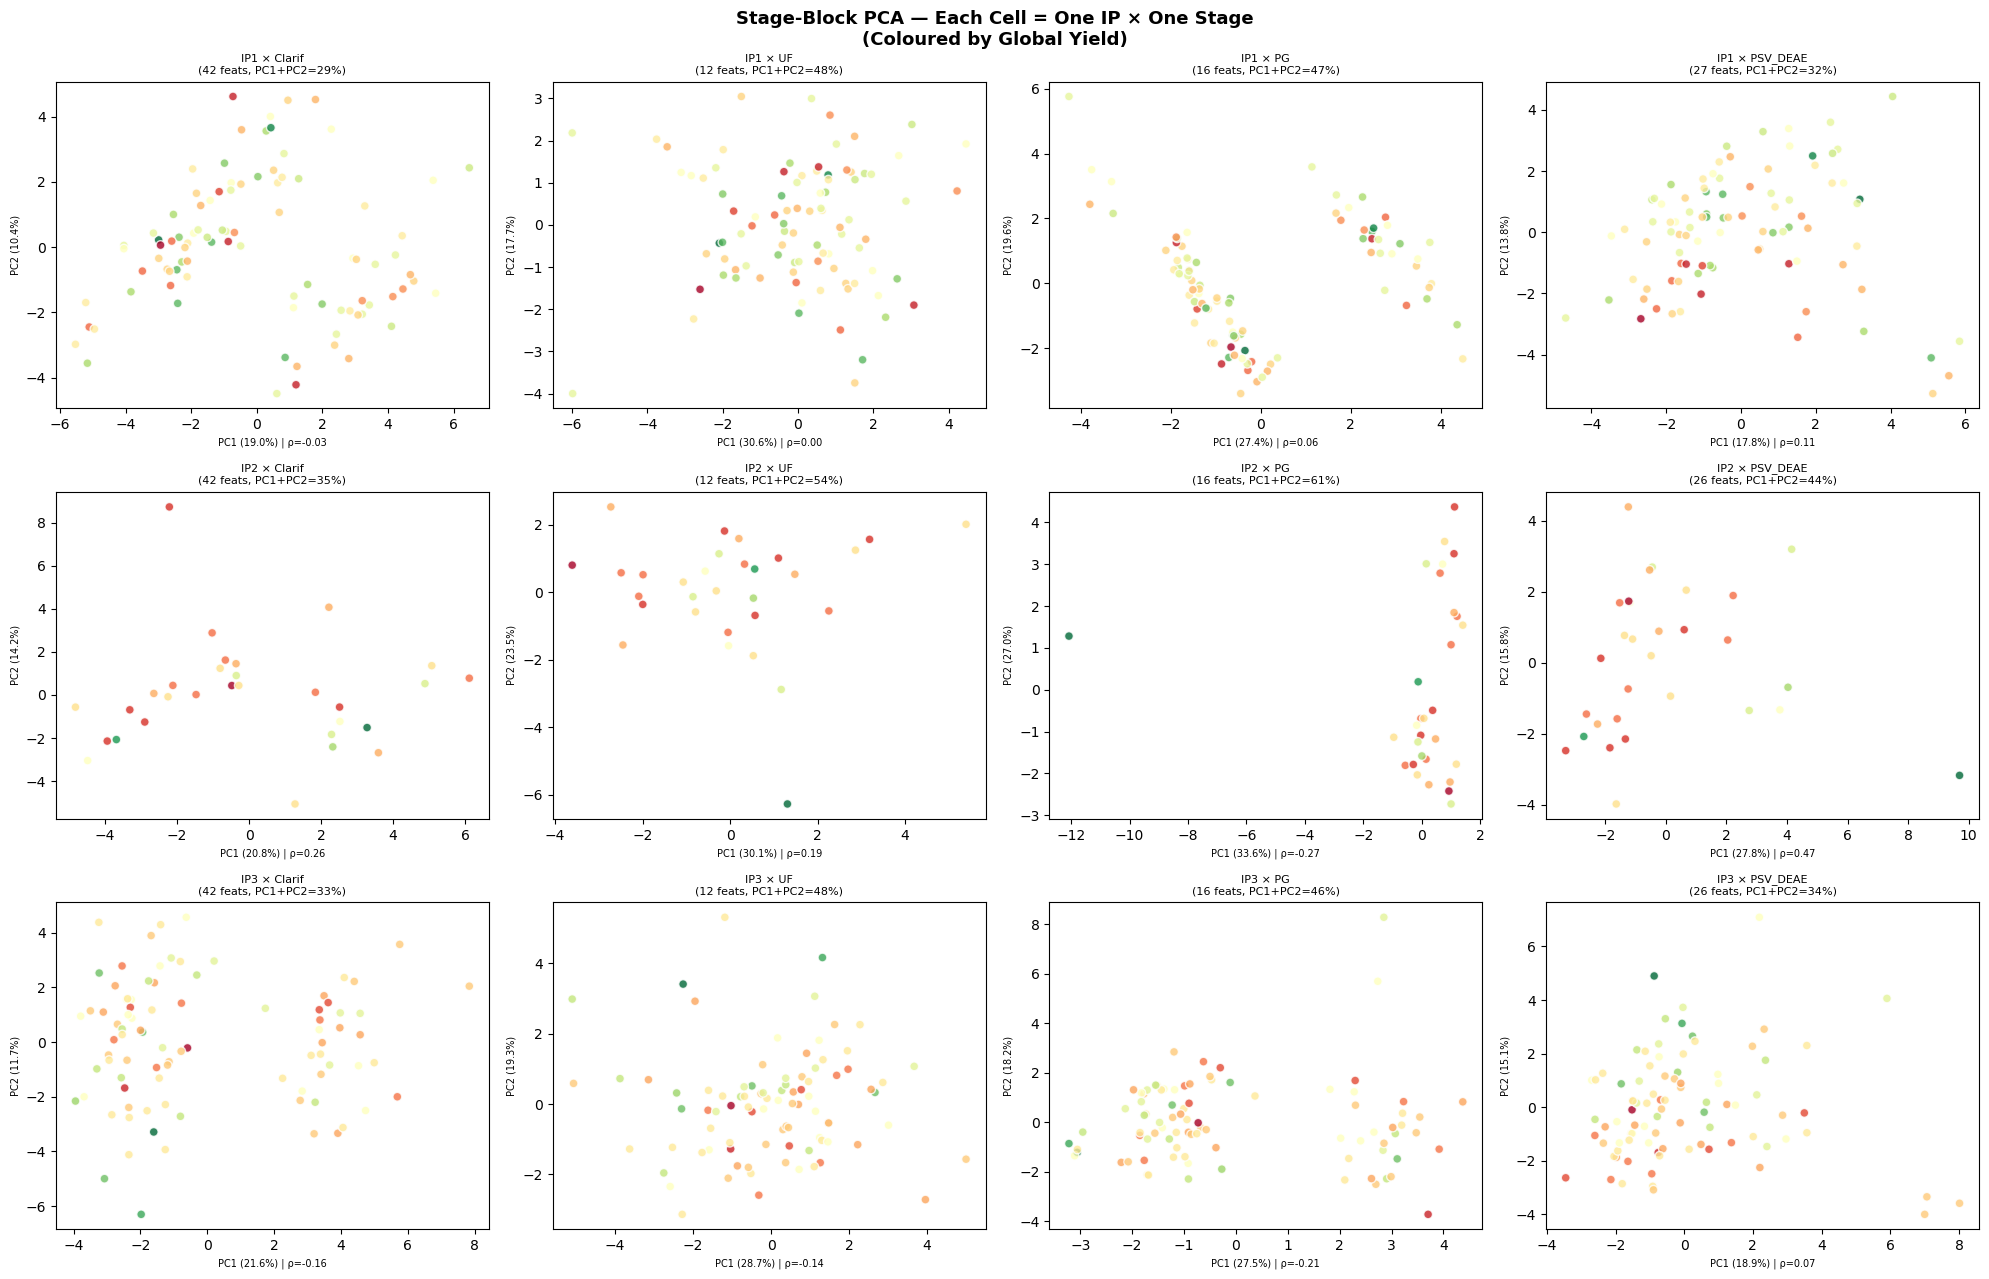


Spearman |ρ| between PC1 and Global Yield (higher = more signal):
       Clarif        UF        PG  PSV_DEAE
IP1  0.027859  0.000315  0.055213  0.107527
IP2  0.260682  0.192923  0.266535  0.470264
IP3  0.162179  0.136088  0.214334  0.074689

[BLOCK 2 DONE — share plot + table above]


In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOCK 2 — Stage-Block PCA per IP
# Goal: which stage's features carry the most within-IP yield signal?
# Fits PCA separately for each (IP x Stage) combination
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("BLOCK 2 — Stage-Block PCA per IP (which stage drives yield?)")
print("=" * 70)
 
stages = list(STAGE_PREFIXES.keys())
ips    = [("IP1", df_ip1), ("IP2", df_ip2), ("IP3", df_ip3)]
 
fig, axes = plt.subplots(len(ips), len(stages), figsize=(20, 13))
fig.suptitle("Stage-Block PCA — Each Cell = One IP × One Stage\n(Coloured by Global Yield)",
             fontsize=13, fontweight="bold")
 
r2_grid = pd.DataFrame(index=[ip for ip, _ in ips], columns=stages, dtype=float)
 
for row_idx, (ip_label, df) in enumerate(ips):
    for col_idx, stage in enumerate(stages):
        prefixes = STAGE_PREFIXES[stage]
        stage_cols = [
            c for c in df.columns
            if any(c.startswith(p) for p in prefixes)
            and pd.api.types.is_numeric_dtype(df[c])
            and c not in [GLOBAL_YIELD_COL] + list(STAGE_YIELD_COLS.values())
            and df[c].nunique() > 3
        ]
 
        ax = axes[row_idx, col_idx]
 
        if len(stage_cols) < 3:
            ax.text(0.5, 0.5, f"< 3 cols\nfound", ha="center", va="center",
                    transform=ax.transAxes, color="gray")
            ax.set_title(f"{ip_label} × {stage}")
            continue
 
        df_c = df[stage_cols + [GLOBAL_YIELD_COL]].dropna(subset=[GLOBAL_YIELD_COL])
        stage_cols_c = [c for c in stage_cols if c in df_c.columns]
 
        try:
            coords, pca = run_pca_2d(df_c, stage_cols_c)
            y_vals = df_c[GLOBAL_YIELD_COL].values
            var1, var2 = pca.explained_variance_ratio_[:2] * 100
 
            sc = ax.scatter(coords[:, 0], coords[:, 1],
                            c=y_vals, cmap="RdYlGn", alpha=0.8,
                            edgecolors="white", s=40)
            ax.set_title(f"{ip_label} × {stage}\n({len(stage_cols_c)} feats, PC1+PC2={var1+var2:.0f}%)",
                         fontsize=8)
            ax.set_xlabel(f"PC1 ({var1:.1f}%)", fontsize=7)
            ax.set_ylabel(f"PC2 ({var2:.1f}%)", fontsize=7)
 
            # Compute correlation of PC1 with yield as a proxy for "signal"
            from scipy.stats import spearmanr
            rho, pval = spearmanr(coords[:, 0], y_vals)
            r2_grid.loc[ip_label, stage] = abs(rho)
            ax.set_xlabel(f"PC1 ({var1:.1f}%) | ρ={rho:.2f}", fontsize=7)
 
        except Exception as e:
            ax.text(0.5, 0.5, f"Error:\n{e}", ha="center", va="center",
                    transform=ax.transAxes, fontsize=7, color="red")
 
plt.tight_layout()
plt.savefig("block2_stage_pca_grid.png", dpi=150, bbox_inches="tight")
plt.show()
 
print("\nSpearman |ρ| between PC1 and Global Yield (higher = more signal):")
print(r2_grid.to_string())
print("\n[BLOCK 2 DONE — share plot + table above]")

Spearman ρ between PC1 and yield (not Pearson): good choice. Batch yield data in pharma is often not normally distributed — you can have a clump of average batches and a tail of low-yield outliers (failed clarification, membrane fouling, etc.). Spearman handles monotonic relationships without assuming linearity, which is appropriate here.
The r2_grid table is the most important output of the whole notebook. Read it like this:

High |ρ| (say > 0.4) for UF × IP1 → the UF stage features in IP1 are strongly monotonically related to yield on PC1. This means UF operating parameters (transmembrane pressure, flux, volume reduction ratio) likely have predictive power.
Low |ρ| everywhere → no single stage dominates yield variation in PCA space → yield is driven by interactions across stages, or the feature naming prefixes are wrong and the stage blocks aren't capturing the right columns.

The < 3 cols found problem is a real blocker. If STAGE_PREFIXES doesn't match column names (e.g. your columns are named "UF1_TMP_bar" but the prefix is "uf_"), an entire row in the grid will be blank. Before interpreting Block 2, you need to verify that each stage block actually contains a reasonable number of features — the code prints the feature count in each subplot title, so check those numbers first.
Why fitting PCA per stage rather than using raw correlations: a single feature's Pearson correlation with yield can be misleading if that feature is collinear with others. PCA on the stage block aggregates the correlated features into a single axis (PC1), which is a more robust measure of the stage's collective predictive power. The Spearman ρ on PC1 is essentially asking: "does this stage's dominant mode of variation track yield?" — much cleaner than 20 individual correlations.


BLOCK 3 — Biplot per IP (top feature loadings)

IP1 — Top 12 features by loading magnitude:
  PSV_PSV - Prot total [mg]                                PC1=-0.019  PC2=+0.246  |mag|=0.247
  PSV_019 PSV - Protein by lowry [µg/ml]                   PC1=-0.035  PC2=+0.242  |mag|=0.244
  PG_DEAE - Volume injected ml [ml]                        PC1=+0.207  PC2=-0.089  |mag|=0.226
  UF_PG - Volume injected ml [ml]                          PC1=+0.207  PC2=-0.087  |mag|=0.225
  clarif_Vol medium transf day 3 [Liter]                   PC1=+0.201  PC2=-0.098  |mag|=0.224
  clarif_Vol medium transf day 4 [Liter]                   PC1=+0.201  PC2=-0.097  |mag|=0.223
  clarif_Vol medium transf day 5 [Liter]                   PC1=+0.200  PC2=-0.097  |mag|=0.222
  clarif_001 Ag cont Elisa virus cult [DU/ml]              PC1=+0.138  PC2=+0.172  |mag|=0.220
  clarif_Harvest - Ag total                                PC1=+0.139  PC2=+0.171  |mag|=0.220
  PSV_PSV - Flow average                            

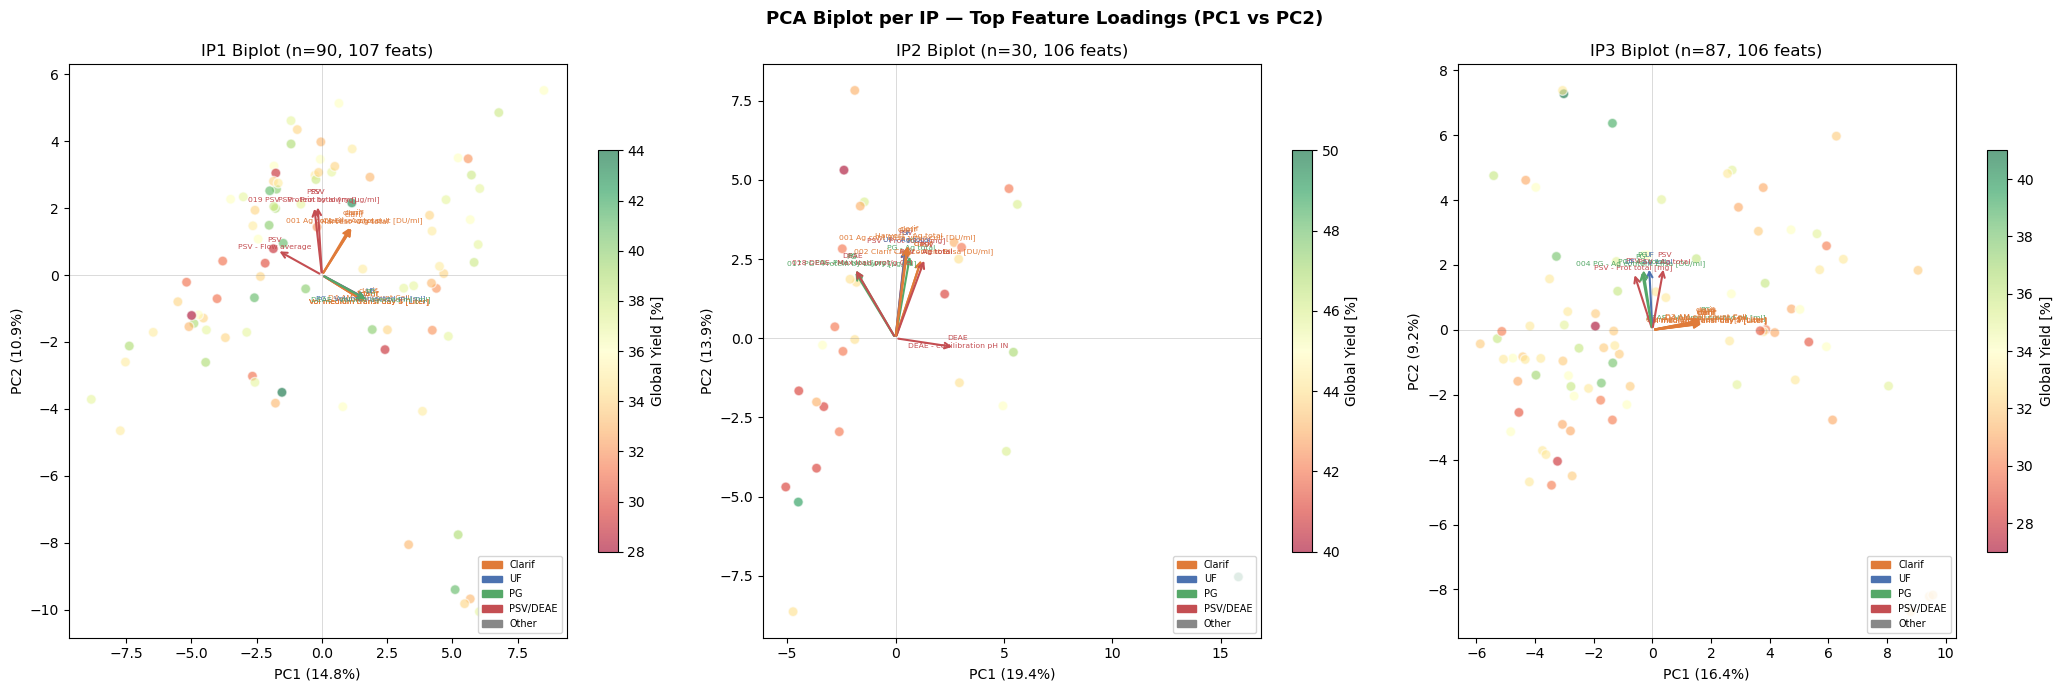


[BLOCK 3 DONE — share plot + printed loading tables]


In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOCK 3 — Biplot per IP (top feature loadings on PC1 & PC2)
# Goal: identify WHICH features drive the spread within each IP
# Key question: are the same features driving within-IP variance in IP1 vs IP3?
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("BLOCK 3 — Biplot per IP (top feature loadings)")
print("=" * 70)
 
N_ARROWS = 12  # number of feature arrows to show
 
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle("PCA Biplot per IP — Top Feature Loadings (PC1 vs PC2)",
             fontsize=13, fontweight="bold")
 
for col_idx, (ip_label, df) in enumerate(ips):
    exclude = [GLOBAL_YIELD_COL, "IP", "Batch"] + list(STAGE_YIELD_COLS.values())
    feat_cols = get_numeric_features(df, exclude_cols=exclude)
    feat_cols = [c for c in feat_cols if df[c].nunique() > 3]
 
    df_c = df[feat_cols + [GLOBAL_YIELD_COL]].dropna(subset=[GLOBAL_YIELD_COL]).reset_index(drop=True)
    feat_cols_c = [c for c in feat_cols if c in df_c.columns]
 
    coords, pca = run_pca_2d(df_c, feat_cols_c)
    coords = coords[:, :2]
    y_vals = df_c[GLOBAL_YIELD_COL].values
    var1, var2 = pca.explained_variance_ratio_[:2] * 100
 
    ax = axes[col_idx]
 
    # Scatter
    sc = ax.scatter(coords[:, 0], coords[:, 1],
                    c=y_vals, cmap="RdYlGn", alpha=0.6,
                    edgecolors="white", s=50, zorder=2)
    plt.colorbar(sc, ax=ax, label="Global Yield [%]", shrink=0.7)
 
    # Loadings arrows — top N by combined PC1+PC2 magnitude
    loadings = pca.components_[:2].T  # shape: (n_features, 2)
    magnitudes = np.sqrt(loadings[:, 0]**2 + loadings[:, 1]**2)
    top_idx = np.argsort(magnitudes)[-N_ARROWS:]
 
    # Scale arrows to fit scatter space
    scale = np.max(np.abs(coords[:, :2])) * 0.85
 
    # Color arrows by stage group
    stage_color_map = {}
    for stage, prefixes in STAGE_PREFIXES.items():
        for p in prefixes:
            stage_color_map[p] = {
                "Clarif": "#E07B39",
                "UF": "#4C72B0",
                "PG": "#55A868",
                "PSV_DEAE": "#C44E52"
            }[stage]
 
    def get_arrow_color(feat_name):
        for p, color in stage_color_map.items():
            if feat_name.startswith(p):
                return color
        return "#888888"
 
    for i in top_idx:
        x_end = loadings[i, 0] * scale
        y_end = loadings[i, 1] * scale
        feat_name = feat_cols_c[i]
        color = get_arrow_color(feat_name)
        ax.annotate("", xy=(x_end, y_end), xytext=(0, 0),
                    arrowprops=dict(arrowstyle="->", color=color, lw=1.5))
        ax.text(x_end * 1.05, y_end * 1.05, feat_name.replace("_", "\n"),
                fontsize=5.5, color=color, ha="center")
 
    # Legend for stage colors
    legend_patches = [
        mpatches.Patch(color="#E07B39", label="Clarif"),
        mpatches.Patch(color="#4C72B0", label="UF"),
        mpatches.Patch(color="#55A868", label="PG"),
        mpatches.Patch(color="#C44E52", label="PSV/DEAE"),
        mpatches.Patch(color="#888888", label="Other"),
    ]
    ax.legend(handles=legend_patches, fontsize=7, loc="lower right")
 
    ax.set_title(f"{ip_label} Biplot (n={len(df_c)}, {len(feat_cols_c)} feats)")
    ax.set_xlabel(f"PC1 ({var1:.1f}%)")
    ax.set_ylabel(f"PC2 ({var2:.1f}%)")
    ax.axhline(0, color="gray", lw=0.5, alpha=0.4)
    ax.axvline(0, color="gray", lw=0.5, alpha=0.4)
 
    # Print top loading features
    print(f"\n{ip_label} — Top {N_ARROWS} features by loading magnitude:")
    for i in reversed(top_idx):
        print(f"  {feat_cols_c[i]:<55s}  PC1={loadings[i,0]:+.3f}  PC2={loadings[i,1]:+.3f}  |mag|={magnitudes[i]:.3f}")
 
plt.tight_layout()
plt.savefig("block3_biplot_per_ip.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n[BLOCK 3 DONE — share plot + printed loading tables]")

What a biplot loading actually means: the loading of feature jj
j on PC1 is the coefficient in the linear combination PC1=∑jwj⋅xjscaled\text{PC1} = \sum_j w_j \cdot x_j^{\text{scaled}}
PC1=∑j​wj​⋅xjscaled​. A high positive loading means that when this feature is high, PC1 is high. A high negative loading means the opposite. Features with loadings near zero don't contribute to PC1.
The magnitude filter √(w_{PC1}^2 + w_{PC2}^2) selects features that matter for either PC1 or PC2 — not just PC1 alone. This is correct because sometimes yield separates along PC2 rather than PC1, and you don't want to miss those features.
Arrow direction relative to yield gradient: this is the key cross-referencing step. If the yield gradient in the scatter (RdYlGn colour) runs left-to-right, and feature X has a strongly positive PC1 loading (arrow pointing right), then high values of X are associated with high yield. That's a candidate for your Ridge model and potentially a process lever to pull.
If arrows cluster by colour (stage): this confirms that process stages co-vary internally. For example, if all orange (Clarif) arrows point in the same direction, it means clarification parameters move together as a block — possibly driven by a single upstream condition like feed titre or cell density. This is useful for Ridge because it tells you that including multiple Clarif features adds redundancy rather than information — you could reduce them to 1–2 representatives.
Divergence between IPs on the biplot: if IP1's top features are mostly PSV/DEAE (red arrows) but IP3's top features are mostly UF (blue arrows), it means the dominant source of process variability differs between IPs. This would explain why a pooled model performs poorly — it's trying to find one set of drivers when the reality is IP-specific.


BLOCK 5 — High vs Low yield batch PCA per IP

IP1:
  Q25=34.0%, Q75=37.0%
  High-yield PC1 mean: 0.25 ± 4.08
  Low-yield  PC1 mean: -0.19 ± 3.58
  Mann-Whitney U p-value: 0.4175  (not significant)

IP2:
  Q25=42.0%, Q75=44.8%
  High-yield PC1 mean: 3.46 ± 6.12
  Low-yield  PC1 mean: -1.55 ± 3.10
  Mann-Whitney U p-value: 0.0825  (not significant)

IP3:
  Q25=32.0%, Q75=34.0%
  High-yield PC1 mean: -0.41 ± 3.61
  Low-yield  PC1 mean: 0.81 ± 4.72
  Mann-Whitney U p-value: 0.4401  (not significant)


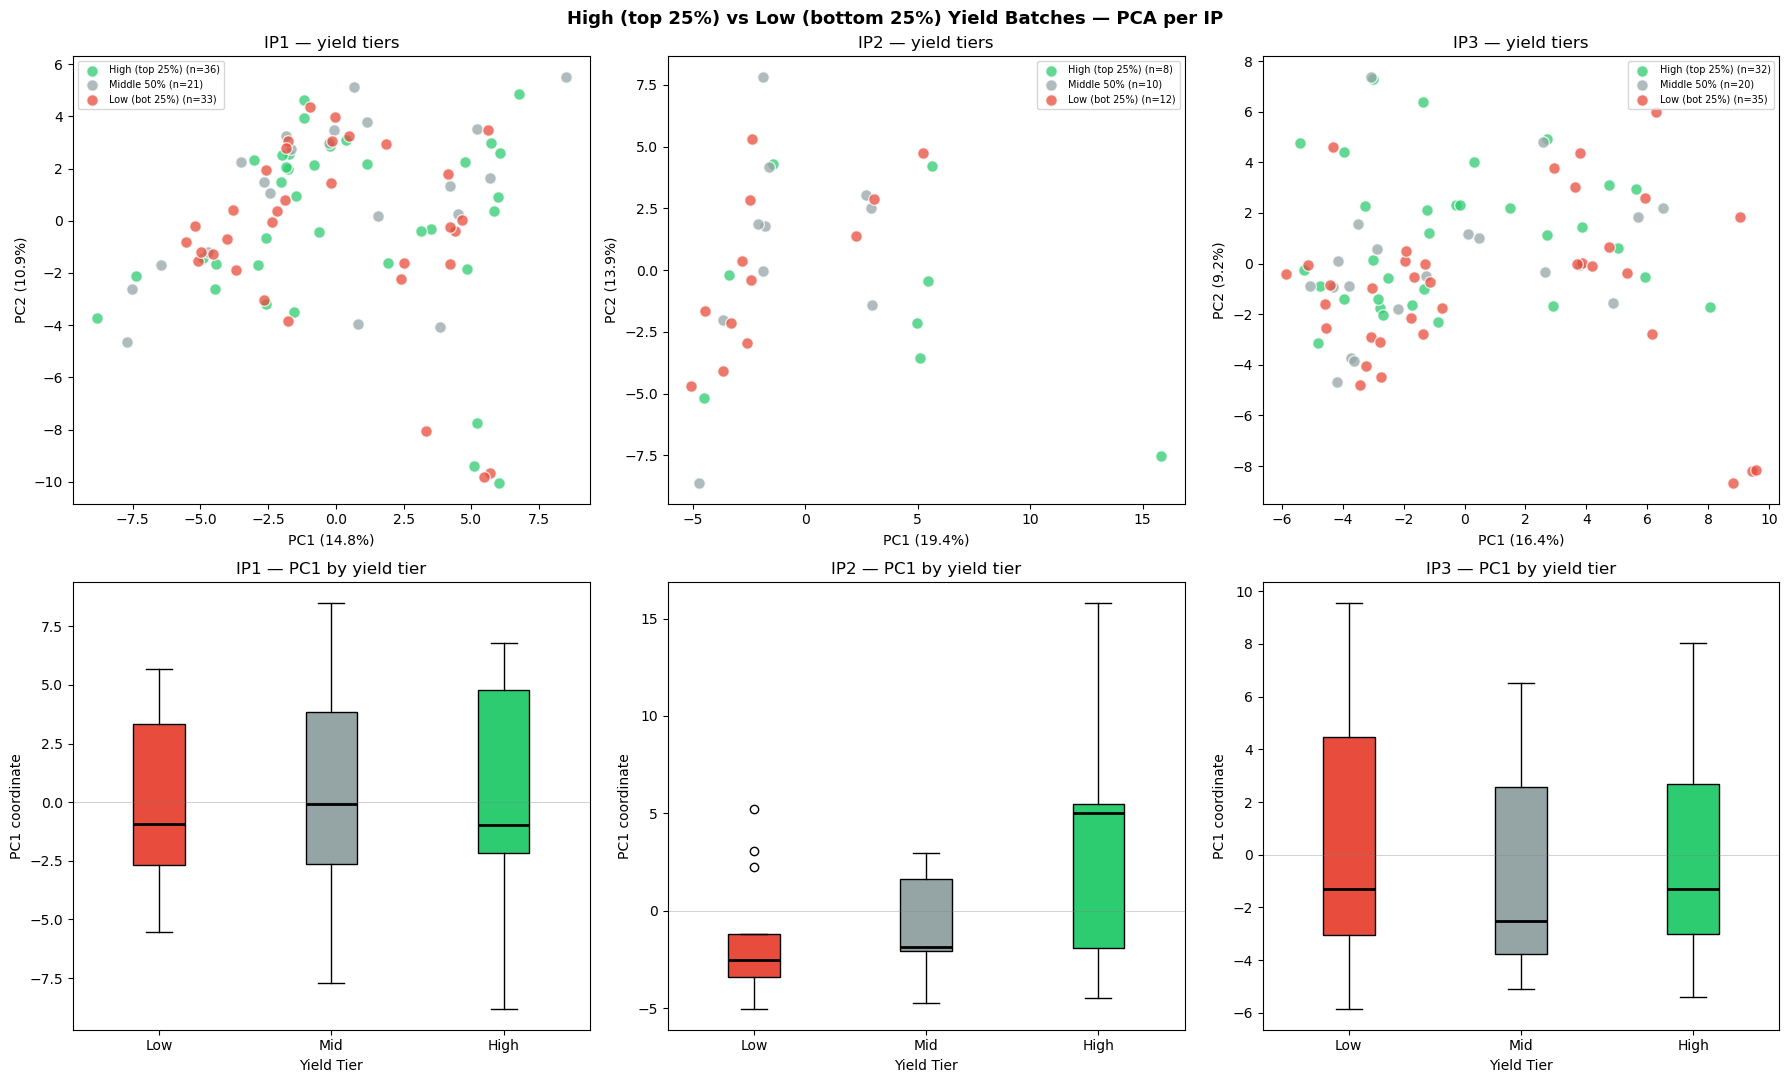


[BLOCK 5 DONE — share plot + printed stats]


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOCK 5 — High vs Low yield batches PCA (per IP)
# Goal: within each IP, do top-25% and bottom-25% batches separate in PCA space?
# This directly answers: "what makes good batches different from bad ones"
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("BLOCK 5 — High vs Low yield batch PCA per IP")
print("=" * 70)
 
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("High (top 25%) vs Low (bottom 25%) Yield Batches — PCA per IP",
             fontsize=13, fontweight="bold")
 
for col_idx, (ip_label, df) in enumerate(ips):
    exclude = [GLOBAL_YIELD_COL, "IP", "Batch"] + list(STAGE_YIELD_COLS.values())
    feat_cols = get_numeric_features(df, exclude_cols=exclude)
    feat_cols = [c for c in feat_cols if df[c].nunique() > 3]
 
    df_c = df[feat_cols + [GLOBAL_YIELD_COL]].dropna(subset=[GLOBAL_YIELD_COL])
    feat_cols_c = [c for c in feat_cols if c in df_c.columns]
    y_vals = df_c[GLOBAL_YIELD_COL].values
 
    q25 = np.percentile(y_vals, 25)
    q75 = np.percentile(y_vals, 75)
    tier = np.where(y_vals >= q75, "High (top 25%)",
           np.where(y_vals <= q25, "Low (bot 25%)", "Middle 50%"))
 
    coords, pca = run_pca_2d(df_c, feat_cols_c)
    var1, var2 = pca.explained_variance_ratio_[:2] * 100
 
    ax_scatter = axes[0, col_idx]
    ax_pc1 = axes[1, col_idx]
 
    color_map = {"High (top 25%)": "#2ecc71", "Middle 50%": "#95a5a6", "Low (bot 25%)": "#e74c3c"}
    for tier_label, color in color_map.items():
        m = tier == tier_label
        ax_scatter.scatter(coords[m, 0], coords[m, 1],
                           label=f"{tier_label} (n={m.sum()})",
                           color=color, alpha=0.75, edgecolors="white", s=70)
 
    ax_scatter.set_title(f"{ip_label} — yield tiers")
    ax_scatter.set_xlabel(f"PC1 ({var1:.1f}%)")
    ax_scatter.set_ylabel(f"PC2 ({var2:.1f}%)")
    ax_scatter.legend(fontsize=7)
 
    # PC1 distribution by tier (box plot)
    data_by_tier = [coords[tier == t, 0] for t in ["Low (bot 25%)", "Middle 50%", "High (top 25%)"]]
    bp = ax_pc1.boxplot(data_by_tier, labels=["Low", "Mid", "High"],
                        patch_artist=True,
                        boxprops=dict(facecolor="#95a5a6"),
                        medianprops=dict(color="black", lw=2))
    for patch, color in zip(bp["boxes"], ["#e74c3c", "#95a5a6", "#2ecc71"]):
        patch.set_facecolor(color)
    ax_pc1.set_title(f"{ip_label} — PC1 by yield tier")
    ax_pc1.set_ylabel("PC1 coordinate")
    ax_pc1.set_xlabel("Yield Tier")
    ax_pc1.axhline(0, color="gray", lw=0.5, alpha=0.5)
 
    # Stats
    h_pc1 = coords[tier == "High (top 25%)", 0]
    l_pc1 = coords[tier == "Low (bot 25%)",  0]
    from scipy.stats import mannwhitneyu
    if len(h_pc1) > 1 and len(l_pc1) > 1:
        stat, pval = mannwhitneyu(h_pc1, l_pc1, alternative="two-sided")
        print(f"\n{ip_label}:")
        print(f"  Q25={q25:.1f}%, Q75={q75:.1f}%")
        print(f"  High-yield PC1 mean: {h_pc1.mean():.2f} ± {h_pc1.std():.2f}")
        print(f"  Low-yield  PC1 mean: {l_pc1.mean():.2f} ± {l_pc1.std():.2f}")
        print(f"  Mann-Whitney U p-value: {pval:.4f}  {'*** SIGNIFICANT' if pval < 0.05 else '(not significant)'}")
 
plt.tight_layout()
plt.savefig("block5_high_vs_low_yield.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n[BLOCK 5 DONE — share plot + printed stats]")

Why percentiles rather than a fixed threshold: using Q25/Q75 is robust to dataset size. With small n (30–50 batches per IP), a fixed threshold like "yield < 70% = low" might give you 2 batches in one class and 40 in the other, making any statistical comparison meaningless. The quartile approach guarantees roughly equal class sizes.
Mann-Whitney U instead of t-test: correct choice. The t-test assumes normality and equal variance — neither guaranteed with small batch counts and potential outliers. Mann-Whitney tests whether one group tends to have higher PC1 values than the other, without distributional assumptions.
Interpreting the p-value in context of small n: with 30–50 batches per IP, your top/bottom 25% groups have roughly 7–12 batches each. Mann-Whitney with n≈10 per group has limited power — you could have a real effect and still get p = 0.12 simply because the sample is too small. So don't interpret "not significant" as "no effect" here. Look at the effect size instead: if the high-yield PC1 mean is 1.8 and the low-yield mean is −0.9, that's a meaningful separation even if p = 0.08.
The boxplot on PC1 by tier is actually more informative than the scatter for this question. It collapses the 2D scatter into a 1D comparison along the axis that matters. You want to see:

Boxes that don't overlap between Low and High → clean separation
Median of High clearly above median of Low
Small within-tier variance (tight boxes) → PC1 is a stable indicator of yield tier

If Low and High boxes heavily overlap but the scatter shows some clustering, it means the yield signal is on PC2, not PC1 — worth checking manually by repeating the Mann-Whitney on coords[:, 1].


BLOCK 6 — Temporal drift (PCA coloured by batch order)

IP1: Spearman ρ (time vs PC1) = 0.829 (p=0.000)
           Spearman ρ (time vs PC2) = -0.082 (p=0.440)
  >> POSSIBLE TEMPORAL DRIFT DETECTED

IP2: Spearman ρ (time vs PC1) = 0.864 (p=0.000)
           Spearman ρ (time vs PC2) = 0.316 (p=0.089)
  >> POSSIBLE TEMPORAL DRIFT DETECTED

IP3: Spearman ρ (time vs PC1) = 0.821 (p=0.000)
           Spearman ρ (time vs PC2) = 0.088 (p=0.416)
  >> POSSIBLE TEMPORAL DRIFT DETECTED


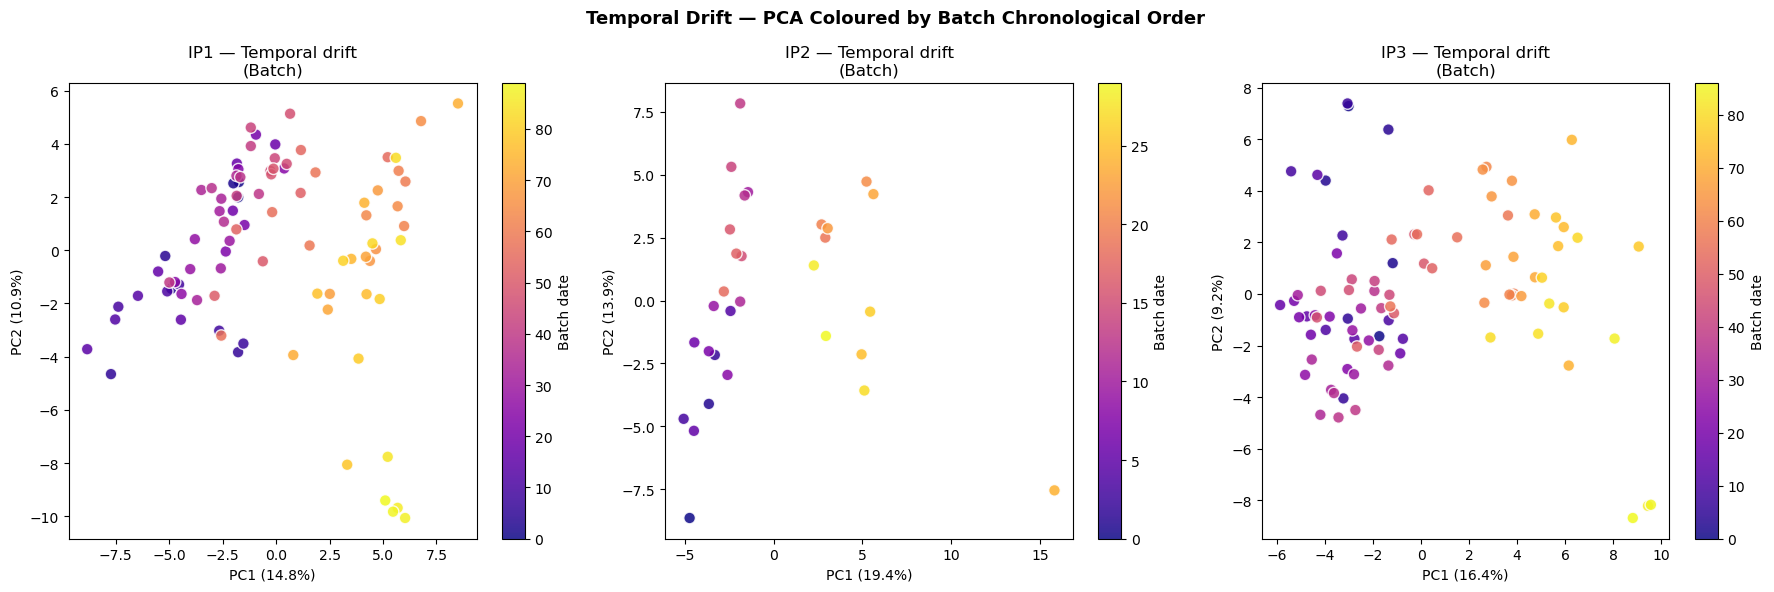


[BLOCK 6 DONE — share plot + printed ρ values]

ALL BLOCKS COMPLETE
Share the 6 PNG files + the printed outputs for interpretation.


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOCK 6 — Temporal drift: PCA coloured by batch date / batch order
# Goal: is there a time trend in process space within each IP?
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("BLOCK 6 — Temporal drift (PCA coloured by batch order)")
print("=" * 70)
 
# Try to find a date / batch index column — adjust as needed
DATE_CANDIDATES = ["Batch", "batch_date", "Start_Date", "Production_Date",
                   "batch_start_date", "BATCH_START_DATE", "Date"]
 
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Temporal Drift — PCA Coloured by Batch Chronological Order",
             fontsize=13, fontweight="bold")
 
for col_idx, (ip_label, df) in enumerate(ips):
    exclude = [GLOBAL_YIELD_COL, "IP", "Batch"] + list(STAGE_YIELD_COLS.values())
    feat_cols = get_numeric_features(df, exclude_cols=exclude)
    feat_cols = [c for c in feat_cols if df[c].nunique() > 3]
 
    # Find the date/order column
    date_col = None
    for cand in DATE_CANDIDATES:
        if cand in df.columns:
            date_col = cand
            break
 
    df_c = df[feat_cols + [GLOBAL_YIELD_COL]].dropna(subset=[GLOBAL_YIELD_COL]).copy()
    feat_cols_c = [c for c in feat_cols if c in df_c.columns]
 
    coords, pca = run_pca_2d(df_c, feat_cols_c)
    var1, var2 = pca.explained_variance_ratio_[:2] * 100
 
    # Use row order as proxy if no date column found
    if date_col and date_col in df.index:
        time_val = pd.to_datetime(df_c[date_col], errors="coerce").values.astype(float)
    else:
        time_val = np.arange(len(df_c))  # row order as proxy
 
    sc = axes[col_idx].scatter(coords[:, 0], coords[:, 1],
                               c=time_val, cmap="plasma", alpha=0.85,
                               edgecolors="white", s=70)
    plt.colorbar(sc, ax=axes[col_idx],
                 label="Batch order (proxy for time)" if date_col is None else "Batch date")
    axes[col_idx].set_title(f"{ip_label} — Temporal drift\n({'row order proxy' if date_col is None else date_col})")
    axes[col_idx].set_xlabel(f"PC1 ({var1:.1f}%)")
    axes[col_idx].set_ylabel(f"PC2 ({var2:.1f}%)")
 
    from scipy.stats import spearmanr
    rho1, p1 = spearmanr(time_val, coords[:, 0])
    rho2, p2 = spearmanr(time_val, coords[:, 1])
    print(f"\n{ip_label}: Spearman ρ (time vs PC1) = {rho1:.3f} (p={p1:.3f})")
    print(f"           Spearman ρ (time vs PC2) = {rho2:.3f} (p={p2:.3f})")
    if abs(rho1) > 0.3 or abs(rho2) > 0.3:
        print(f"  >> POSSIBLE TEMPORAL DRIFT DETECTED")
 
plt.tight_layout()
plt.savefig("block6_temporal_drift.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n[BLOCK 6 DONE — share plot + printed ρ values]")
 
print("\n" + "=" * 70)
print("ALL BLOCKS COMPLETE")
print("Share the 6 PNG files + the printed outputs for interpretation.")
print("=" * 70)

Why this matters for your Ridge model: LOO-CV assumes that each left-out batch is exchangeable with the training set — i.e. the process hasn't fundamentally changed. If there's temporal drift (process parameters shifting over months as equipment ages, operators change, raw material suppliers vary), then early batches and late batches aren't from the same distribution. Your LOO-CV estimate would be optimistic because it mixes data from different time periods in training and test.
The row-index proxy for time: if no date column is found, the code falls back to row order. This is valid only if the CSV is stored in chronological order — which is usually the case for SAP exports (batches are entered as they run). Worth verifying this assumption with your domain expert at GSK.
Spearman ρ thresholds:

|ρ| < 0.2: no meaningful drift, LOO-CV is safe as-is
0.2 < |ρ| < 0.4: mild drift, worth monitoring but probably not a modelling crisis
|ρ| > 0.4: significant drift — you should consider time-aware cross-validation, or at minimum flag that model predictions may degrade for future batches that look different from historical ones

What a drift pattern looks like in the scatter: if the plasma colormap forms a smooth arc or trajectory (early batches on one end, late batches on the other), that's a clean drift. If colours are randomly mixed, there's no temporal structure. A broken pattern — say, two clusters of similar colours far apart — could indicate a process change event (equipment replacement, SOP update) rather than gradual drift, which is a different kind of problem for modelling.